In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#
os.makedirs("landing_zone", exist_ok=True)
os.makedirs("delta_lake", exist_ok=True)
os.makedirs("quarantine", exist_ok=True)

print("Directories created successfully")

Directories created successfully


In [4]:
# 1. Good Batch (PASS)
good_data = pd.DataFrame({
    "patient_id": [101, 102, 103, 104],
    "patient_phone": ["0501234567", "0559876543", "0541112233", "0564445566"],
    "age": [25, 40, 32, 50],
    "visit_date": ["2026-01-10", "2026-02-15", "2026-03-01", "2026-03-20"],
    "diagnosis": ["Flu", "Diabetes", "Checkup", "Hypertension"]
})

# 2. Bad Batch (FAIL)
bad_data = pd.DataFrame({
    "patient_id": [101, 101, None, 105],
    "patient_phone": ["0501234567", "0501234567", "0540000000", "0561111111"],
    "age": [-5, 40, 150, 45],
    "visit_date": ["2026-01-10", "2030-01-01", "2026-03-01", "2026-03-20"],
    "diagnosis": ["Flu", "Diabetes", None, "Hypertension"]
})

# Save to landing zone
good_data.to_csv("landing_zone/good_patients.csv", index=False)
bad_data.to_csv("landing_zone/bad_patients.csv", index=False)

print("Test datasets generated and saved to landing_zone!")

Test datasets generated and saved to landing_zone!


In [5]:
class HealthDataQualityEngine:
    def __init__(self, df):
        self.df = df.copy()

    def check_uniqueness(self):
        return self.df.duplicated(subset=["patient_id"], keep=False)

    def check_completeness(self):
        return self.df[["patient_id", "diagnosis"]].isnull().any(axis=1)

    def check_range_validity(self):
        return (self.df["age"] < 0) | (self.df["age"] > 120)

    def check_temporal_consistency(self):
        dates = pd.to_datetime(self.df["visit_date"], errors="coerce")
        return dates > pd.Timestamp.now()

    def run_all_checks(self):
        c1 = self.check_uniqueness()
        c2 = self.check_completeness()
        c3 = self.check_range_validity()
        c4 = self.check_temporal_consistency()
        return c1 | c2 | c3 | c4

print("Engine class registered!")

Engine class registered!


In [6]:
def process_health_pipeline(file_path):
    print(f"\n--- Processing File: {file_path} ---")
    df = pd.read_csv(file_path, dtype={"patient_phone": str})

    engine = HealthDataQualityEngine(df)
    bad_mask = engine.run_all_checks()

    clean_df = df[~bad_mask]
    quarantine_df = df[bad_mask]

    file_name = os.path.basename(file_path)

    if not clean_df.empty:
        clean_path = os.path.join("delta_lake", f"clean_{file_name}")
        clean_df.to_csv(clean_path, index=False)
        print(f"SUCCESS: {len(clean_df)} records stored in Delta Lake -> {clean_path}")

    if not quarantine_df.empty:
        quarantine_path = os.path.join("quarantine", f"quarantine_{file_name}")
        quarantine_df.to_csv(quarantine_path, index=False)
        print(f"WARNING: {len(quarantine_df)} records sent to Quarantine -> {quarantine_path}")

# Run execution
process_health_pipeline("landing_zone/good_patients.csv")
process_health_pipeline("landing_zone/bad_patients.csv")


--- Processing File: landing_zone/good_patients.csv ---
SUCCESS: 4 records stored in Delta Lake -> delta_lake/clean_good_patients.csv

--- Processing File: landing_zone/bad_patients.csv ---
SUCCESS: 1 records stored in Delta Lake -> delta_lake/clean_bad_patients.csv


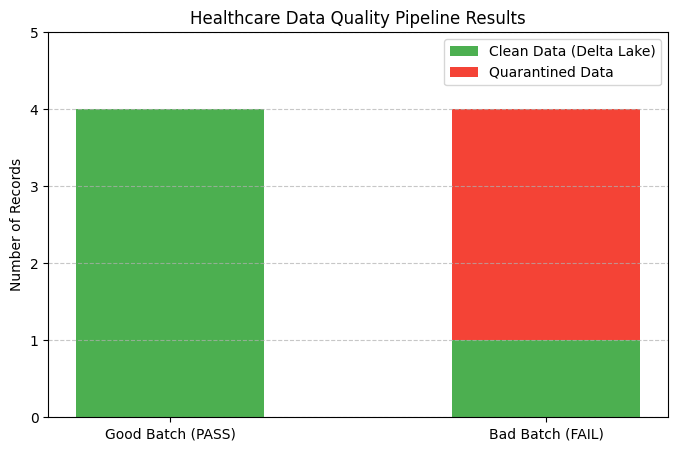

In [7]:
import matplotlib.pyplot as plt

#
categories = ['Good Batch (PASS)', 'Bad Batch (FAIL)']
clean_records = [4, 1]        # clean records
quarantined_records = [0, 3]  # invalid records

#
fig, ax = plt.subplots(figsize=(8, 5))

#
p1 = ax.bar(categories, clean_records, label='Clean Data (Delta Lake)', color='#4CAF50', width=0.5)
#
p2 = ax.bar(categories, quarantined_records, bottom=clean_records, label='Quarantined Data', color='#F44336', width=0.5)

ax.set_ylabel('Number of Records')
ax.set_title('Healthcare Data Quality Pipeline Results')
ax.set_ylim(0, 5)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()